In [4]:
import numpy as np
import matplotlib.pyplot as plt
from metrics import  * 

M_reel=np.loadtxt("Matrix.txt",dtype=int)
M_reel=np.array(M_reel)

n_utilisateurs, n_articles = M_reel.shape

L,idx_cache = masque(M_reel,0.10)
for (i,j) in idx_cache:
    L[i,j] = 9 

Omega = np.argwhere(L != 9)
evaluations = L[L != 9].astype(float)
#Parametres du SGD
k = 8
alpha = 0.02
reg = 0.0001
max_iteration = 200
#Taille de l'echantillons emprimiques choisis 
taille_lot = 10000

U = np.random.normal(0, 0.05, (n_utilisateurs, k)) 
V = np.random.normal(0, 0.05, (n_articles, k))
Bu = np.zeros(n_utilisateurs)
Bi = np.zeros(n_articles)


moyenne_globale = np.mean(evaluations)
n_echantillons = len(Omega)
print(f"\nDébut de l'entraînement (Alpha={alpha}, Reg={reg}, k={k})...")

#Optimisation de la fonciton cout par mini Batch SGD pour trouver U et V
for iteration in range(max_iteration):
    p = np.random.permutation(n_echantillons)
    Omega = Omega[p]
    evaluations = evaluations[p]

    perte_totale = 0

    for debut in range(0, n_echantillons, taille_lot):
        fin = min(debut + taille_lot, n_echantillons)
        idx_lot = Omega[debut:fin]
        r_lot = evaluations[debut:fin]

        i = idx_lot[:, 0]
        j = idx_lot[:, 1]

        produit_scalaire = np.sum(U[i] * V[j], axis=1)
        pred = moyenne_globale + Bu[i] + Bi[j] + produit_scalaire
        
        erreur = r_lot - pred
        perte_totale += np.sum(erreur**2)
        np.add.at(Bu, i, alpha * (erreur - reg * Bu[i]))
        np.add.at(Bi, j, alpha * (erreur - reg * Bi[j]))

        V_j_ancien = V[j]
        U_i_ancien = U[i]

        grad_U = alpha * (erreur[:, None] * V_j_ancien - reg * U_i_ancien)
        grad_V = alpha * (erreur[:, None] * U_i_ancien - reg * V_j_ancien)

        np.add.at(U, i, grad_U)
        np.add.at(V, j, grad_V)

    if (iteration + 1) % 10 == 0:
        print(f"Iteration {iteration+1}/{max_iteration}")

R_complet_pred = moyenne_globale + Bu[:, np.newaxis] + Bi[np.newaxis, :] + np.dot(U, V.T)
#Seuillage des elements de R_complet_pred
for i in range (n_utilisateurs) : 
    for j in range(n_articles):
            if R_complet_pred[i,j ] > 2 :
                R_complet_pred[i,j ]  = 2 
            R_complet_pred[i,j] = round_seuil(R_complet_pred[i,j],1.7)
#Calcul des metrics
metrics(M_reel,R_complet_pred,idx_cache)

for i,j in idx_cache :
    R_complet_pred[i,j] =M_reel[i,j] 
#Sauvegarde des matrices 
np.savetxt("Matrice_predit_SGD.txt",R_complet_pred,fmt='%d', delimiter=' ')



Début de l'entraînement (Alpha=0.02, Reg=0.0001, k=8)...
Iteration 10/200
Iteration 20/200
Iteration 30/200
Iteration 40/200
Iteration 50/200
Iteration 60/200
Iteration 70/200
Iteration 80/200
Iteration 90/200
Iteration 100/200


KeyboardInterrupt: 

In [ ]:
# code est pour calculer la courbe PR 
#L = []
#for idx in idx_cache:
#    i, j = idx
#    L.append((R_complet_pred[i, j], M_reel[i, j]))

#L_trie = sorted(L, key=lambda x: x[0],reverse = True)





def recherche_meilleur_seuil(L_trie):
    resultats = []
    pas = 0.05

    seuil_min = 0.0
    seuil_max = 2.0
    seuils = np.arange(seuil_min, seuil_max + pas, pas)
    for seuil in seuils:
        precision, rappel = calculer_metriques(L_trie, seuil)

        resultats.append({
            'seuil': seuil,
            'precision': precision,
            'rappel': rappel,
        })
        
    return resultats

def tracer_courbe_precision_rappel(historique_resultats):
    
    precisions = [d['precision'] for d in historique_resultats]
    rappels = [d['rappel'] for d in historique_resultats]
    plt.plot(rappels, precisions)
    plt.show()
#historique_resultats = recherche_meilleur_seuil(L_trie)
#tracer_courbe_precision_rappel(historique_resultats)

def calculer_courbe_precision_rappel(L_trie):
    # Classe positive = 2
    total_positifs = sum(1 for _, r in L_trie if r == 2)

    VP = 0
    FP = 0

    precisions = []
    rappels = []

    i = 0
    n = len(L_trie)

    while i < n:
        score_courant = L_trie[i][0]

        # traiter TOUS les exemples avec le même score
        while i < n and L_trie[i][0] == score_courant:
            _, reel = L_trie[i]
            if reel == 2:
                VP += 1
            else:
                FP += 1
            i += 1

        # calcul des métriques APRÈS ajout du groupe
        precision = VP / (VP + FP) if (VP + FP) > 0 else 0
        rappel = VP / total_positifs if total_positifs > 0 else 0

        precisions.append(precision)
        rappels.append(rappel)

    return precisions, rappels
#precisions, rappels = calculer_courbe_precision_rappel(L_trie)

#plt.figure(figsize=(6,5))
#plt.plot(rappels, precisions, marker='o')
#plt.xlabel("Rappel")
#plt.ylabel("Précision")
#plt.title("Courbe Précision–Rappel (classe positive = 2)")
#plt.grid()
#plt.show()


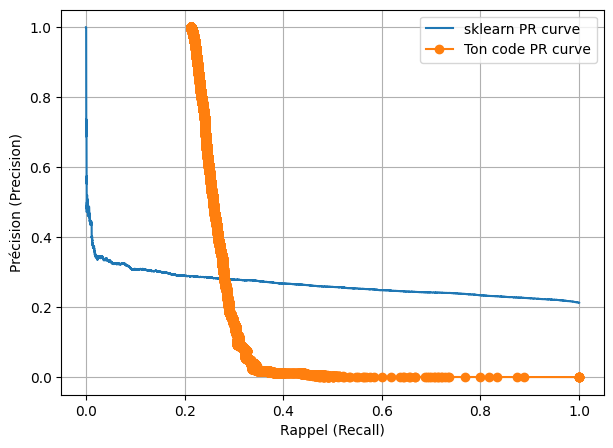

In [40]:
#Verification supplementaire de la courbe PR avec sklearn.metrics
from sklearn.metrics import precision_recall_curve

y_scores = [p for p, _ in L]
y_true = [1 if r == 2 else 0 for _, r in L]

prec, rec, _ = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(7,5))
plt.plot(rec, prec, label='sklearn PR curve')
plt.plot(prec, rec, 'o-', label='Ton code PR curve')
plt.xlabel("Rappel (Recall)")
plt.ylabel("Précision (Precision)")
plt.legend()
plt.grid(True)
plt.show()
